# Regresja 
Estymacja ceny mieszkań na podstawie zbioru danych **AmesHousing**

### Importowanie potrzebnych bibliotek

In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Wczytywanie danych

In [189]:
df = pd.read_csv("domy.csv", index_col=[0], na_values=['?'])
df_copy = df.copy()

### Wstępna analiza danych

In [190]:
df.columns

Index(['MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley',
       'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope',
       'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
       'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd',
       'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'Wo

W zbiorze danych występują braki danych. </br> Według dokumentacji niektóre z nich zostały umieszczone celowo.

In [191]:
missing_values = df.isna().sum()
missing_values[missing_values > 0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

Niektóre zmienne nie posiadają wszystkich wartości opisanych w dokumentacji

Brak wartości *CBlock*

Text(0.5, 1.0, 'Hisogram zmiennej MasVnrType')

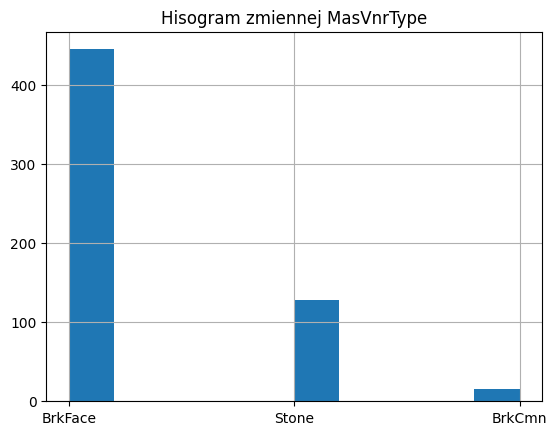

In [192]:
df.MasVnrType.hist()
plt.title("Hisogram zmiennej MasVnrType")

Brak wartości *Po*

Text(0.5, 1.0, 'Histogram zmiennej BsmtQual')

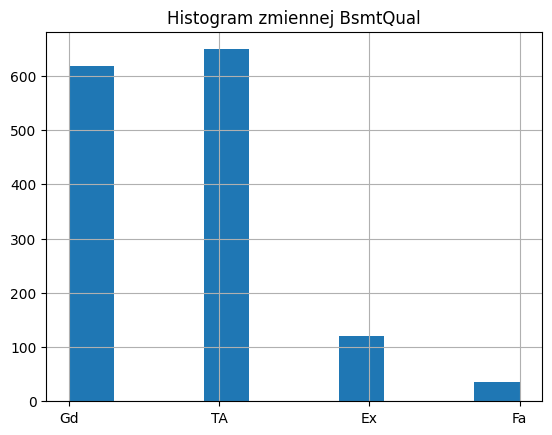

In [193]:
df.BsmtQual.hist()
plt.title("Histogram zmiennej BsmtQual")

Brak wartości *Ex*

Text(0.5, 1.0, 'Histogram zmiennej BsmtCond')

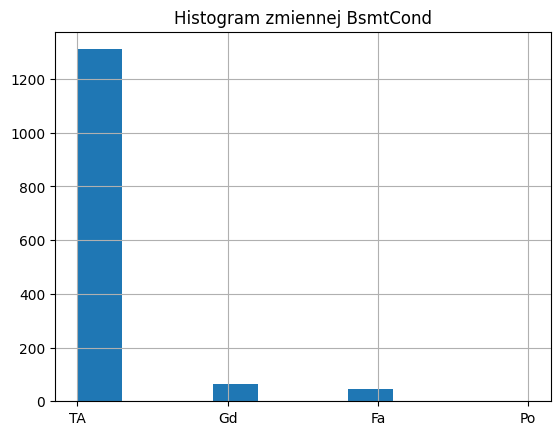

In [194]:
df.BsmtCond.hist()
plt.title("Histogram zmiennej BsmtCond")

### Preprocessing danych

##### Dealing with false N/A values

In [195]:
df.loc[df.LotFrontage.isna(), "LotFrontage"] = 0

##### Missing values

In [196]:
print("MasVnrArea")
print(f"Values equal to zero: {df.MasVnrArea[df.MasVnrArea == 0].count()}   <-- lack of masonry veneer")
print(f"Missing values:")
print(df.MasVnrArea[df.MasVnrArea.isna()])


MasVnrArea
Values equal to zero: 861   <-- lack of masonry veneer
Missing values:
Id
235    NaN
530    NaN
651    NaN
937    NaN
974    NaN
978    NaN
1244   NaN
1279   NaN
Name: MasVnrArea, dtype: float64


##### One-hot encoding
TODO: Condition 1 and 2 merge, and Exterior 1/2
Misc feature to set as val

In [197]:
nominal_columns = ["MSSubClass", "MSZoning", "Street", "LandContour", "LotConfig", 
                   "Neighborhood", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", "Foundation",
                   "Heating", "CentralAir", "SaleType", "SaleCondition", "Condition1", "Condition2",
                   "Exterior1st", "Exterior2nd"]
nominal_columns_na = ["Alley", "MasVnrType", "GarageType", "MiscFeature"]
df = pd.get_dummies(df, drop_first=True, columns=nominal_columns)
df = pd.get_dummies(df, drop_first=False, columns=nominal_columns_na)

Zbiór danych zawiera *Misc features*, oraz ich wartości. <br>
Pomysł enkodowania obecności *Misc features* poprzez ich wartości może tracić informacje - 2 rekordy z istnejącą cechą mają wartość 0.0

In [198]:
# misc_feat = pd.get_dummies(df.MiscFeature, drop_first=False, dtype=np.float64)

# misc_feat.mul(df.MiscVal, axis=0).head(20)
# print(f"No miscelaneous feature count:        {len(df.MiscFeature[df.MiscFeature.isna()])}")
# print(f"Miscelaneous feature value = 0 count: {df.MiscVal[df.MiscVal == 0.0].count()}")
#misc_feat.head(20)

##### Ordinal encoding

In [199]:
lot_shape_mapping = {
    'Reg': 0.0,
    'IR1': 1.0/3.0,
    'IR2': 2.0/3.0,
    'IR3': 1.0
}
df.LotShape = df.LotShape.map(lot_shape_mapping)
print(df.LotShape.dtype)

utilities_mapping = {
    'ELO': 0.0,
    'NoSeWa': 1.0/3.0,
    'NoSewr': 2.0/3.0,
    'AllPub': 1.0
}
df.Utilities = df.Utilities.map(utilities_mapping)

land_slope_mapping = {
    'Gtl': 0.0,
    'Mod': 1.0/2.0,
    'Sev': 1.0
}
df.LandSlope = df.LandSlope.map(land_slope_mapping)

qual_mapping = {
    'Po': 0.0,
    'Fa': 1.0/4.0,
    'TA': 2.0/4.0,
    'Gd': 3.0/4.0,
    'Ex': 1.0
}
df.ExterQual = df.ExterQual.map(qual_mapping)
df.ExterCond = df.ExterCond.map(qual_mapping)
df.HeatingQC = df.HeatingQC.map(qual_mapping)
df.KitchenQual = df.KitchenQual.map(qual_mapping)

qual_mapping_na = {
    np.nan: 0.0,
    'Po': 1.0/5.0,
    'Fa': 2.0/5.0,
    'TA': 3.0/5.0,
    'Gd': 4.0/5.0,
    'Ex': 1.0
}
df.BsmtQual = df.BsmtQual.map(qual_mapping_na)
df.BsmtCond = df.BsmtCond.map(qual_mapping_na)
df.FireplaceQu = df.FireplaceQu.map(qual_mapping_na)
df.GarageQual = df.GarageQual.map(qual_mapping_na)
df.GarageCond = df.GarageCond.map(qual_mapping_na)
df.PoolQC = df.PoolQC.map(qual_mapping_na)

bsmt_exposure_mapping = {
    np.nan: 0.0,
    'No': 0.0,
    'Mn': 1.0/3.0,
    'Av': 2.0/3.0,
    'Gd': 1.0
}
df.BsmtExposure = df.BsmtExposure.map(bsmt_exposure_mapping)

bsmt_fin_type_mapping = {
    np.nan: 0.0,
    'Unf': 1.0/6.0,
    'LwQ': 2.0/6.0,
    'Rec': 3.0/6.0,
    'BLQ': 4.0/6.0,
    'ALQ': 5.0/6.0,
    'GLQ': 1.0
}
df.BsmtFinType1 = df.BsmtFinType1.map(bsmt_fin_type_mapping)
df.BsmtFinType2 = df.BsmtFinType2.map(bsmt_fin_type_mapping)

electrical_mapping = {
    'FuseP': 0.0,
    'Mix': 1.0/4.0,
    'FuseF': 2.0/4.0,
    'FuseA': 3.0/4.0,
    'SBrkr': 1.0
}
df.Electrical = df.Electrical.map(electrical_mapping)

functional_mapping = {
    'Sal': 0.0,
    'Sev': 1.0/7.0,
    'Maj2': 2.0/7.0,
    'Maj1': 3.0/7.0,
    'Mod': 4.0/7.0,
    'Min2': 5.0/7.0,
    'Min1': 6.0/7.0,
    'Typ': 1.0
}
df.Functional = df.Functional.map(functional_mapping)

garage_finish_mapping = {
    np.nan: 0.0,
    'Unf': 1.0/3.0,
    'RFn': 2.0/3.0,
    'Fin': 1.0
}
df.GarageFinish = df.GarageFinish.map(garage_finish_mapping)

paved_drive_mapping = {
    'N': 0.0,
    'P': 1.0/2.0,
    'Y': 1.0
}
df.PavedDrive = df.PavedDrive.map(paved_drive_mapping)

fence_mapping = {
    np.nan: 0.0,
    'MnWw': 1.0/4.0,
    'GdWo': 2.0/4.0,
    'MnPrv': 3.0/4.0,
    'GdPrv': 1.0
}
df.Fence = df.Fence.map(fence_mapping)

float64


Odrzucenie outlierów zalecane przez dokumentacją

<Figure size 640x480 with 0 Axes>

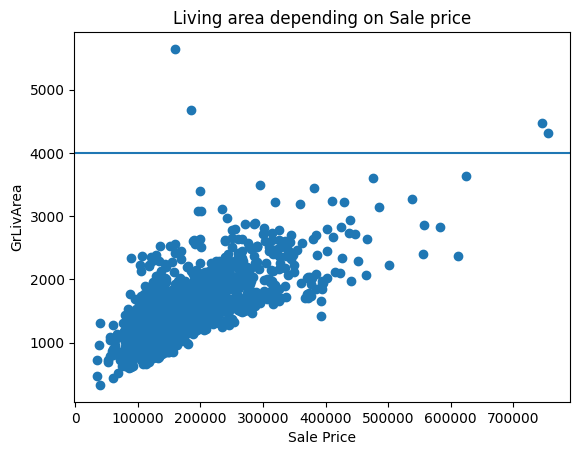

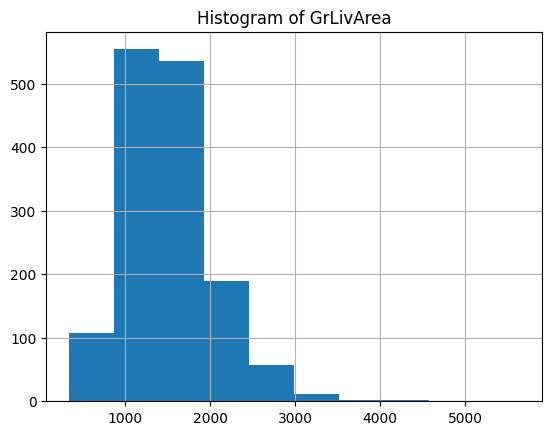

<Figure size 640x480 with 0 Axes>

In [200]:
plt.scatter(df.SalePrice, df.GrLivArea)
plt.title("Living area depending on Sale price")
plt.xlabel("Sale Price")
plt.ylabel("GrLivArea")
plt.axhline(4000)
plt.figure()
df["GrLivArea"].hist()
plt.title("Histogram of GrLivArea")
df = df[df.GrLivArea <= 4000]
plt.figure()

Heterodeskatyczność *Sale price*</br>
Zastosowano metodę zalecaną w dokumentacji

Text(0.5, 1.0, 'Histogram log(SalrPrice)')

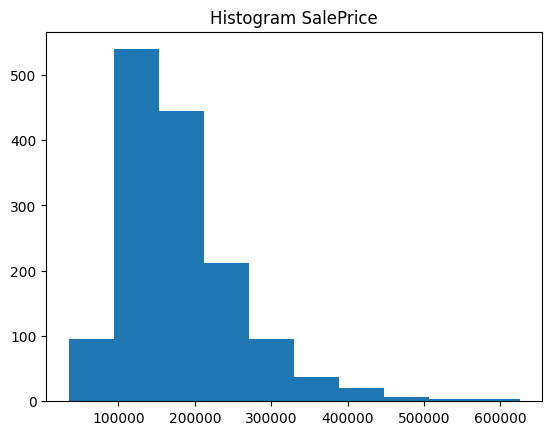

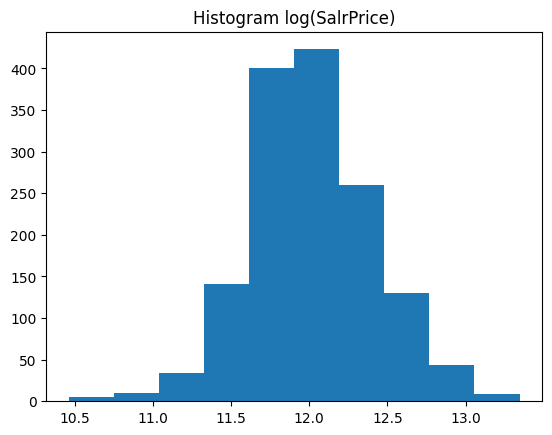

In [201]:
plt.hist(df.SalePrice)
plt.title("Histogram SalePrice")
df.SalePrice = np.log(df.SalePrice)
plt.figure()
plt.hist(df.SalePrice)
plt.title("Histogram log(SalrPrice)")

Podział danych na dane wejściowe i zmienną estymowaną, oraz normalizacja danych do wartości z zakresu 0.0-1.0

In [202]:
Y = df.SalePrice
X = df.drop(["SalePrice"], axis=1)
X = X.astype(np.float64)
X = (X - X.min()) / (X.max() - X.min())
X.describe()

,LotFrontage,LotArea,LotShape,Utilities,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,MiscFeature_Gar2,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC
count,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1448.000000,...,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000
mean,0.183054,0.042762,0.135073,0.999313,0.031250,0.565400,0.572030,0.718735,0.580323,0.063805,...,0.004121,0.595467,0.013049,0.059753,0.006181,0.265797,0.001374,0.001374,0.033654,0.000687
std,0.108236,0.046090,0.192831,0.026207,0.138296,0.152185,0.139246,0.218852,0.344202,0.110837,...,0.064084,0.490970,0.113525,0.237110,0.078405,0.441908,0.037050,0.037050,0.180398,0.026207
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.134185,0.029161,0.000000,1.000000,0.000000,0.444444,0.500000,0.594203,0.279167,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.201278,0.038180,0.000000,1.000000,0.000000,0.555556,0.500000,0.724638,0.725000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.252396,0.048087,0.333333,1.000000,0.000000,0.666667,0.625000,0.927536,0.900000,0.102656,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Analiza danych

Data wybudowania domu niekoniecznie zmniejsza jego cenę

Text(0, 0.5, 'Cena mieszkania')

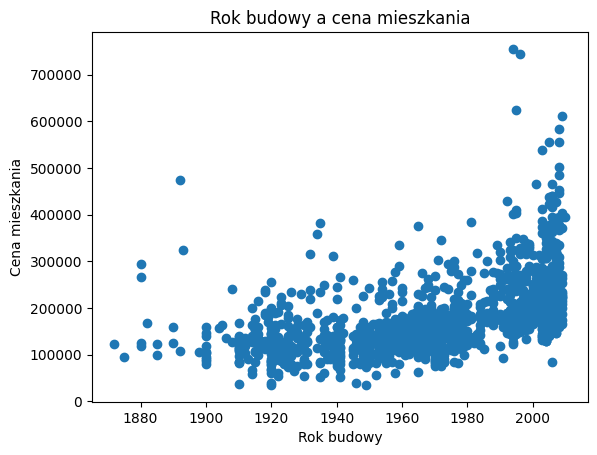

In [203]:
plt.scatter(df_copy.YearBuilt, df_copy.SalePrice)
plt.title("Rok budowy a cena mieszkania")
plt.xlabel("Rok budowy")
plt.ylabel("Cena mieszkania")

Wpływ dodatkowych cech *Condition 1/2* na SalePrice

<Axes: title={'center': 'SalePrice'}, xlabel='Condition2'>

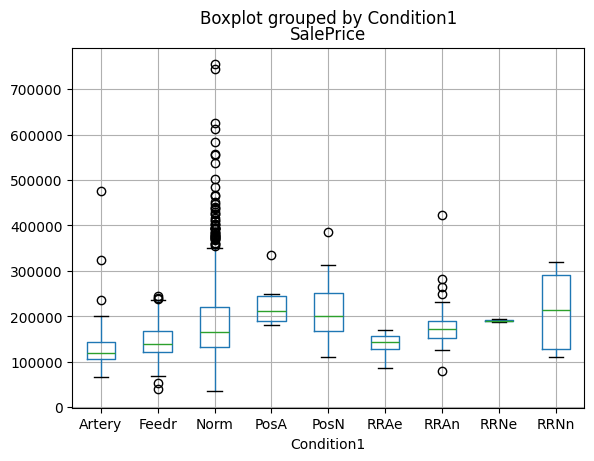

<Figure size 640x480 with 0 Axes>

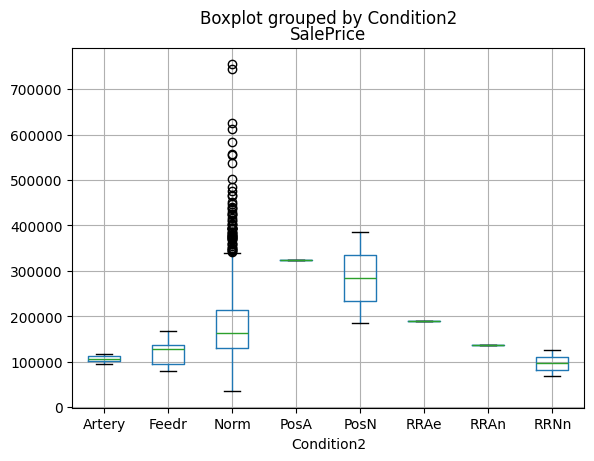

In [204]:
df_copy.boxplot(by="Condition1", column="SalePrice")
plt.figure()
df_copy.boxplot(by="Condition2", column="SalePrice")

##### Analiza korelacji

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
MSSubClass,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,-0.065649,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,0.040229,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,-0.049107,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,-0.067759,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,-0.072319,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,-0.050117,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420
BsmtFinSF2,-0.065649,0.049900,0.111170,-0.059119,0.040229,-0.049107,-0.067759,-0.072319,-0.050117,1.000000,...,0.067898,0.003093,0.036543,-0.029993,0.088871,0.041709,0.004940,-0.015211,0.031706,-0.011378


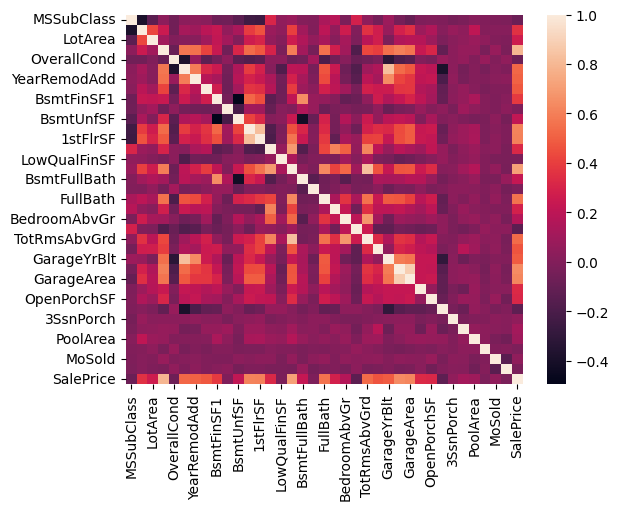

In [205]:
sns.heatmap(df_copy.corr(numeric_only=True))
df_copy.corr(numeric_only=True)

Wysoką korelację z ceną końcową (na poziomie ~0.75) mają ogólna jakość mieszkania oraz powierzchnia mieszkalna. </br>
Zauważalną korelację z ceną końcową (na poziomie ~0.5) mają rok produkcji i remontu, powierzchnia piwnicy, pojemność garażu, ilość pełnych łazienek oraz obecność kominka.

<Axes: >

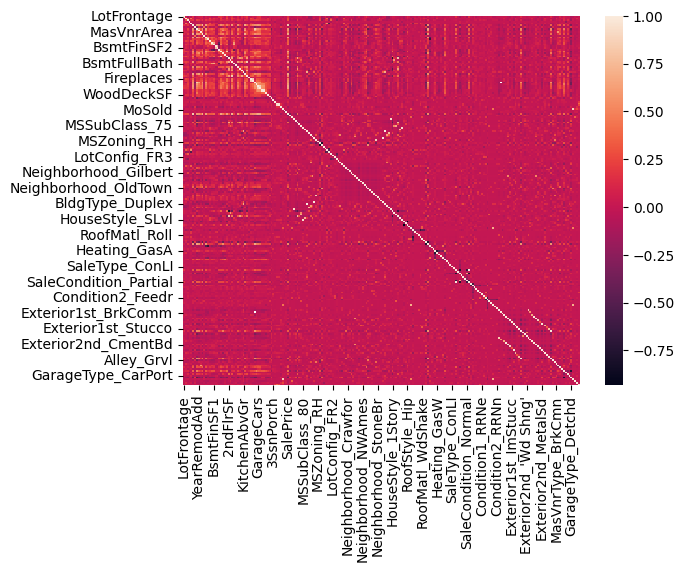

In [206]:
sns.heatmap(df.corr())